# Fig 16 – Distribution des classes (camemberts) + timeline 24h

**Pré-requis** : `24h_summary.csv`, `24h_events.csv` et les dossiers `audios_*` dans le même répertoire.

Les emojis sont rendus via **Pillow** (NotoColorEmoji sur Linux, Segoe UI Emoji sur Windows,
Apple Color Emoji sur macOS). Détection automatique de la police selon l'OS.

Structure :
- **Ligne 0** : toutes les données
- **Lignes 1–3** : top-20 / top-50 / top-100 pics les plus forts

## 0. Imports & configuration

In [2]:
import sys, os, glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Détection automatique de la police emoji (cross-platform) ────────────────
def find_emoji_font():
    """Retourne le chemin vers une police emoji couleur selon l'OS, ou None."""
    if sys.platform == 'win32':
        winfonts = os.environ.get('WINDIR', 'C:/Windows') + '/Fonts/'
        for name in ['seguiemj.ttf', 'seguisym.ttf']:
            p = winfonts + name
            if os.path.exists(p):
                return p
    elif sys.platform == 'darwin':
        p = '/System/Library/Fonts/Apple Color Emoji.ttc'
        if os.path.exists(p):
            return p
    else:  # Linux
        for p in ['/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf',
                  '/usr/share/fonts/noto/NotoColorEmoji.ttf']:
            if os.path.exists(p):
                return p
        hits = glob.glob('/usr/share/fonts/**/*ColorEmoji*.ttf', recursive=True)
        if hits:
            return hits[0]
    return None

EMOJI_FONT_PATH = find_emoji_font()
if EMOJI_FONT_PATH:
    print(f'Police emoji trouvée : {EMOJI_FONT_PATH}')
else:
    print('AVERTISSEMENT : aucune police emoji couleur trouvée.')
    print('  -> Les emojis seront affichés en texte brut (rendu limité).')
    print('  -> Sur Windows : installez la police Segoe UI Emoji (incluse dans Windows 10/11).')
    print('  -> Sur Linux   : sudo apt install fonts-noto-color-emoji')

Police emoji trouvée : C:\WINDOWS/Fonts/seguiemj.ttf


In [3]:
# ── Paramètres audio ──────────────────────────────────────────────────────────
SR          = 22050
WINDOW_S    = 1.0
HOP_S       = 0.5
MIN_GAP_S   = 30.0

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS2IDX_FULL = {
    'Fond sonore': 0, '2/3RM': 1, 'Voiture': 2, 'Bus': 3, 'Camion': 4,
    'Tram': 5, 'Klaxon': 6, 'Chien': 7, 'Travaux': 8, 'Sirène': 9
}
CLASSES = [k for k in CLASS2IDX_FULL if k != 'Tram']

# ── Emojis par classe ─────────────────────────────────────────────────────────
CLASS_EMOJI = {
    'Voiture':      '\U0001f697',
    'Camion':       '\U0001f69b',
    '2/3RM':        '\U0001f3cd\ufe0f',
    'Bus':          '\U0001f68c',
    'Chien':        '\U0001f415',
    'Sirène':       '\U0001f6a8',
    'Klaxon':       '\U0001f4e2',
    'Klaxon/Sirène':'\U0001f6a8',
    'Travaux':      '\U0001f528',
    'Fond sonore':  '\U0001f507',
}
PERIOD_EMOJI = {
    'Soirée':  '\U0001f306',
    'Nuit':    '\U0001f319',
    'Journée': '\u2600\ufe0f',
}

# ── Couleurs ──────────────────────────────────────────────────────────────────
CLASS_COLORS = {
    'Fond sonore':  '#b0bec5',
    '2/3RM':        '#f44336',
    'Voiture':      '#42a5f5',
    'Bus':          '#66bb6a',
    'Camion':       '#ff7043',
    'Klaxon':       '#ffca28',
    'Chien':        '#26c6da',
    'Travaux':      '#8d6e63',
    'Sirène':       '#ec407a',
    'Klaxon/Sirène':'#ec407a',
}

# ── Périodes ──────────────────────────────────────────────────────────────────
period_ranges = [('Soirée', 16, 24), ('Nuit', 24, 32), ('Journée', 32, 40)]
PERIOD_COLORS = {'Soirée': '#ff7043', 'Nuit': '#3949ab', 'Journée': '#fdd835'}

# ── Dossiers audio ────────────────────────────────────────────────────────────
FOLDERS        = [Path('audios_16h_00h'), Path('audios_00h_08h'), Path('audios_08h_16h')]
FOLDER_START_H = [16, 24, 32]
PERIOD_LABELS  = ['Soirée', 'Nuit', 'Journée']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'font.size': 10,
})
print('Config OK')

Config OK


## 1. Fonctions utilitaires

In [4]:
# ── Rendu emoji via Pillow (avec cache) ───────────────────────────────────────
_emoji_cache = {}
_emoji_font  = ImageFont.truetype(EMOJI_FONT_PATH, 109) if EMOJI_FONT_PATH else None

def emoji_to_rgba(emoji):
    """
    Rend un emoji en tableau RGBA (H x W x 4) via la police système.
    Résultat mis en cache pour éviter les re-rendus.
    Lève RuntimeError si aucune police n'est disponible.
    """
    if _emoji_font is None:
        raise RuntimeError(
            'Aucune police emoji trouvée.\n'
            'Windows : la police Segoe UI Emoji (seguiemj.ttf) doit être installée.\n'
            'Linux   : sudo apt install fonts-noto-color-emoji\n'
            'macOS   : Apple Color Emoji est incluse par défaut.'
        )
    if emoji in _emoji_cache:
        return _emoji_cache[emoji]
    img  = Image.new('RGBA', (140, 140), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)
    draw.text((10, 10), emoji, font=_emoji_font, embedded_color=True)
    bb = img.getbbox()
    if bb:
        img = img.crop(bb)
    arr = np.array(img)
    _emoji_cache[emoji] = arr
    return arr

def place_emoji(ax, emoji, x, y, zoom=0.22, zorder=10):
    """Insère un emoji centré en (x, y) dans les coordonnées data de ax."""
    im = OffsetImage(emoji_to_rgba(emoji), zoom=zoom)
    ab = AnnotationBbox(im, (x, y), frameon=False, zorder=zorder)
    ax.add_artist(ab)

# ── Helpers généraux ──────────────────────────────────────────────────────────
# Mapping anglais -> français
_FR = {
    'Car': 'Voiture', 'Truck': 'Camion', 'MC': '2/3RM',
    'Dog': 'Chien', 'Horn': 'Klaxon', 'Siren': 'Sirène',
    'Construction': 'Travaux', 'BG': 'Fond sonore',
    'Bus': 'Bus', 'Tram': 'Tram',
}

def normalize_class(cls):
    cls = _FR.get(cls, cls)  # traduction anglais -> français
    return 'Klaxon/Sirène' if cls in ('Klaxon', 'Sirène') else cls

def to_emoji(cls):
    return CLASS_EMOJI.get(normalize_class(cls), '?')

def abs_hour_label(abs_h):
    return f"{int(abs_h % 24):02d}h D2" if abs_h >= 24 else f"{int(abs_h % 24):02d}h D1"

def get_period(abs_h):
    if 16 <= abs_h < 24:   return 'Soirée'
    elif 24 <= abs_h < 32: return 'Nuit'
    else:                  return 'Journée'

def filename_to_abs_hour(filename, folder_start_h):
    parts = Path(filename).stem.split('_')
    if len(parts) >= 3:
        ts = parts[2]
        h, m, s = int(ts[0:2]), int(ts[2:4]), int(ts[4:6])
        local_h = h + m / 60 + s / 3600
        return local_h if folder_start_h == 16 else local_h + 24
    return folder_start_h

def class_at_time(filename, t, df_events):
    evs = df_events[
        (df_events['filename'] == filename) &
        (~df_events['class'].isin(['BG', 'Tram'])) &
        (df_events['t_start'] <= t) &
        (df_events['t_end']   >= t)
    ]
    if not evs.empty:
        return normalize_class(evs.loc[evs['conf_mean'].idxmax(), 'class'])
    evs2 = df_events[
        (df_events['filename'] == filename) &
        (~df_events['class'].isin(['BG', 'Tram']))
    ].copy()
    if evs2.empty:
        return 'BG'
    evs2['dist'] = ((evs2['t_start'] + evs2['t_end']) / 2 - t).abs()
    return normalize_class(evs2.loc[evs2['dist'].idxmin(), 'class'])

def add_period_shading(ax):
    for pname, ps, pe in period_ranges:
        ax.axvspan(ps, pe, color=PERIOD_COLORS[pname], alpha=0.07, zorder=0)
    for xv in [24, 32]:
        ax.axvline(xv, color='#bbb', linewidth=1.2, linestyle=':', zorder=4)

def strip_axes(ax):
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(''); ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(False)

def draw_pie_with_labels(ax, counts, title, emoji_zoom=0.22, r_emoji=1.22, r_label=1.50):
    """
    Camembert avec emojis + noms de classes affichés autour de chaque part.
    counts : pd.Series indexée par nom de classe.
    """
    labels = list(counts.index)
    values = list(counts.values)
    colors = [CLASS_COLORS.get(normalize_class(c), '#999') for c in labels]

    wedges, _, autotexts = ax.pie(
        values,
        labels=[''] * len(labels),
        colors=colors,
        autopct='%1.0f%%',
        startangle=90,
        pctdistance=0.68,
        wedgeprops=dict(linewidth=1.8, edgecolor='white')
    )
    for at in autotexts:
        at.set_fontsize(8.5)
        at.set_fontweight('bold')
        at.set_color('white')

    for wedge, cls in zip(wedges, labels):
        # Ignorer les parts trop petites
        if (wedge.theta2 - wedge.theta1) / 360 < 0.03:
            continue
        angle = (wedge.theta1 + wedge.theta2) / 2
        rad   = np.radians(angle)
        # Emoji
        xe = r_emoji * np.cos(rad)
        ye = r_emoji * np.sin(rad)
        place_emoji(ax, to_emoji(cls), xe, ye, zoom=emoji_zoom)
        # Nom de classe
        xl = r_label * np.cos(rad)
        yl = r_label * np.sin(rad)
        ha = 'left' if xl >= 0 else 'right'
        ax.text(xl, yl, cls, ha=ha, va='center', fontsize=8,
                fontweight='bold',
                color=CLASS_COLORS.get(normalize_class(cls), '#333'))

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

# Vérification rapide des couleurs de classe
print('Couleurs de classe OK:', list(CLASS_COLORS.keys()))

Couleurs de classe OK: ['Fond sonore', '2/3RM', 'Voiture', 'Bus', 'Camion', 'Klaxon', 'Chien', 'Travaux', 'Sirène', 'Klaxon/Sirène']


## 2. Chargement des CSV

In [5]:
df_files  = pd.read_csv('24h_summary.csv')
df_events = pd.read_csv('24h_events.csv')
df_events['class_norm'] = df_events['class'].apply(normalize_class)

print(f'24h_summary.csv : {len(df_files)} fichiers')
print(f'24h_events.csv  : {len(df_events)} événements')

24h_summary.csv : 2738 fichiers
24h_events.csv  : 12839 événements


## 3. Scan audio – pics de niveau

In [6]:
win_samples = int(SR * WINDOW_S)
hop_samples = int(SR * HOP_S)

print('Scan des fichiers audio...')
peaks = []
for folder, start_h, period in zip(FOLDERS, FOLDER_START_H, PERIOD_LABELS):
    audio_files = sorted(folder.glob('*.wav'))
    if not audio_files:
        print(f'  Aucun WAV dans {folder} – ignoré.')
        continue
    for audio_path in tqdm(audio_files, desc=period):
        try:
            abs_h = filename_to_abs_hour(audio_path.name, start_h)
            y, _  = librosa.load(str(audio_path), sr=SR, mono=True)
            for s in range(0, len(y) - win_samples + 1, hop_samples):
                window  = y[s: s + win_samples]
                rms_val = np.sqrt(np.mean(window ** 2))
                db_val  = float(20 * np.log10(rms_val + 1e-9))
                peaks.append({'filename': audio_path.name,
                              'folder':   folder.name,
                              'period':   period,
                              'abs_hour': abs_h,
                              't_peak':   s / SR,
                              'db_peak':  db_val})
        except Exception as ex:
            print(f'  [ERREUR] {audio_path.name} : {ex}')

df_peaks = pd.DataFrame(peaks)
print(f'{len(df_peaks):,} fenêtres analysées')

Scan des fichiers audio...


Soirée:   0%|          | 0/959 [00:00<?, ?it/s]

Nuit:   0%|          | 0/960 [00:00<?, ?it/s]

Journée:   0%|          | 0/819 [00:00<?, ?it/s]

161,542 fenêtres analysées


## 4. Dédoublonnage top-N

In [7]:
def get_top_n_peaks(n, df_peaks, df_events, base_df=None):
    df_sorted = df_peaks.sort_values('db_peak', ascending=False).reset_index(drop=True)
    selected, kept_times = [], []
    for _, row in df_sorted.iterrows():
        t_abs = (row['abs_hour'] - 16) * 3600 + row['t_peak']
        if any(abs(t_abs - t2) < MIN_GAP_S for t2 in kept_times):
            continue
        selected.append(row)
        kept_times.append(t_abs)
        if len(selected) == n:
            break
    df_n = pd.DataFrame(selected).reset_index(drop=True)
    if base_df is not None and 'class_at_peak' in base_df.columns:
        known = base_df.set_index(['filename', 't_peak'])['class_at_peak'].to_dict()
        df_n['class_at_peak'] = df_n.apply(
            lambda r: known.get((r['filename'], r['t_peak']),
                                class_at_time(r['filename'], r['t_peak'], df_events)), axis=1)
    else:
        df_n['class_at_peak'] = df_n.apply(
            lambda r: class_at_time(r['filename'], r['t_peak'], df_events), axis=1)
    return df_n

print('top-20...');  peaks_20  = get_top_n_peaks(20,  df_peaks, df_events)
print('top-50...');  peaks_50  = get_top_n_peaks(50,  df_peaks, df_events, base_df=peaks_20)
print('top-100...'); peaks_100 = get_top_n_peaks(100, df_peaks, df_events, base_df=peaks_50)
print('Terminé.')

top-20...
top-50...
top-100...
Terminé.


## 5. Figure 16

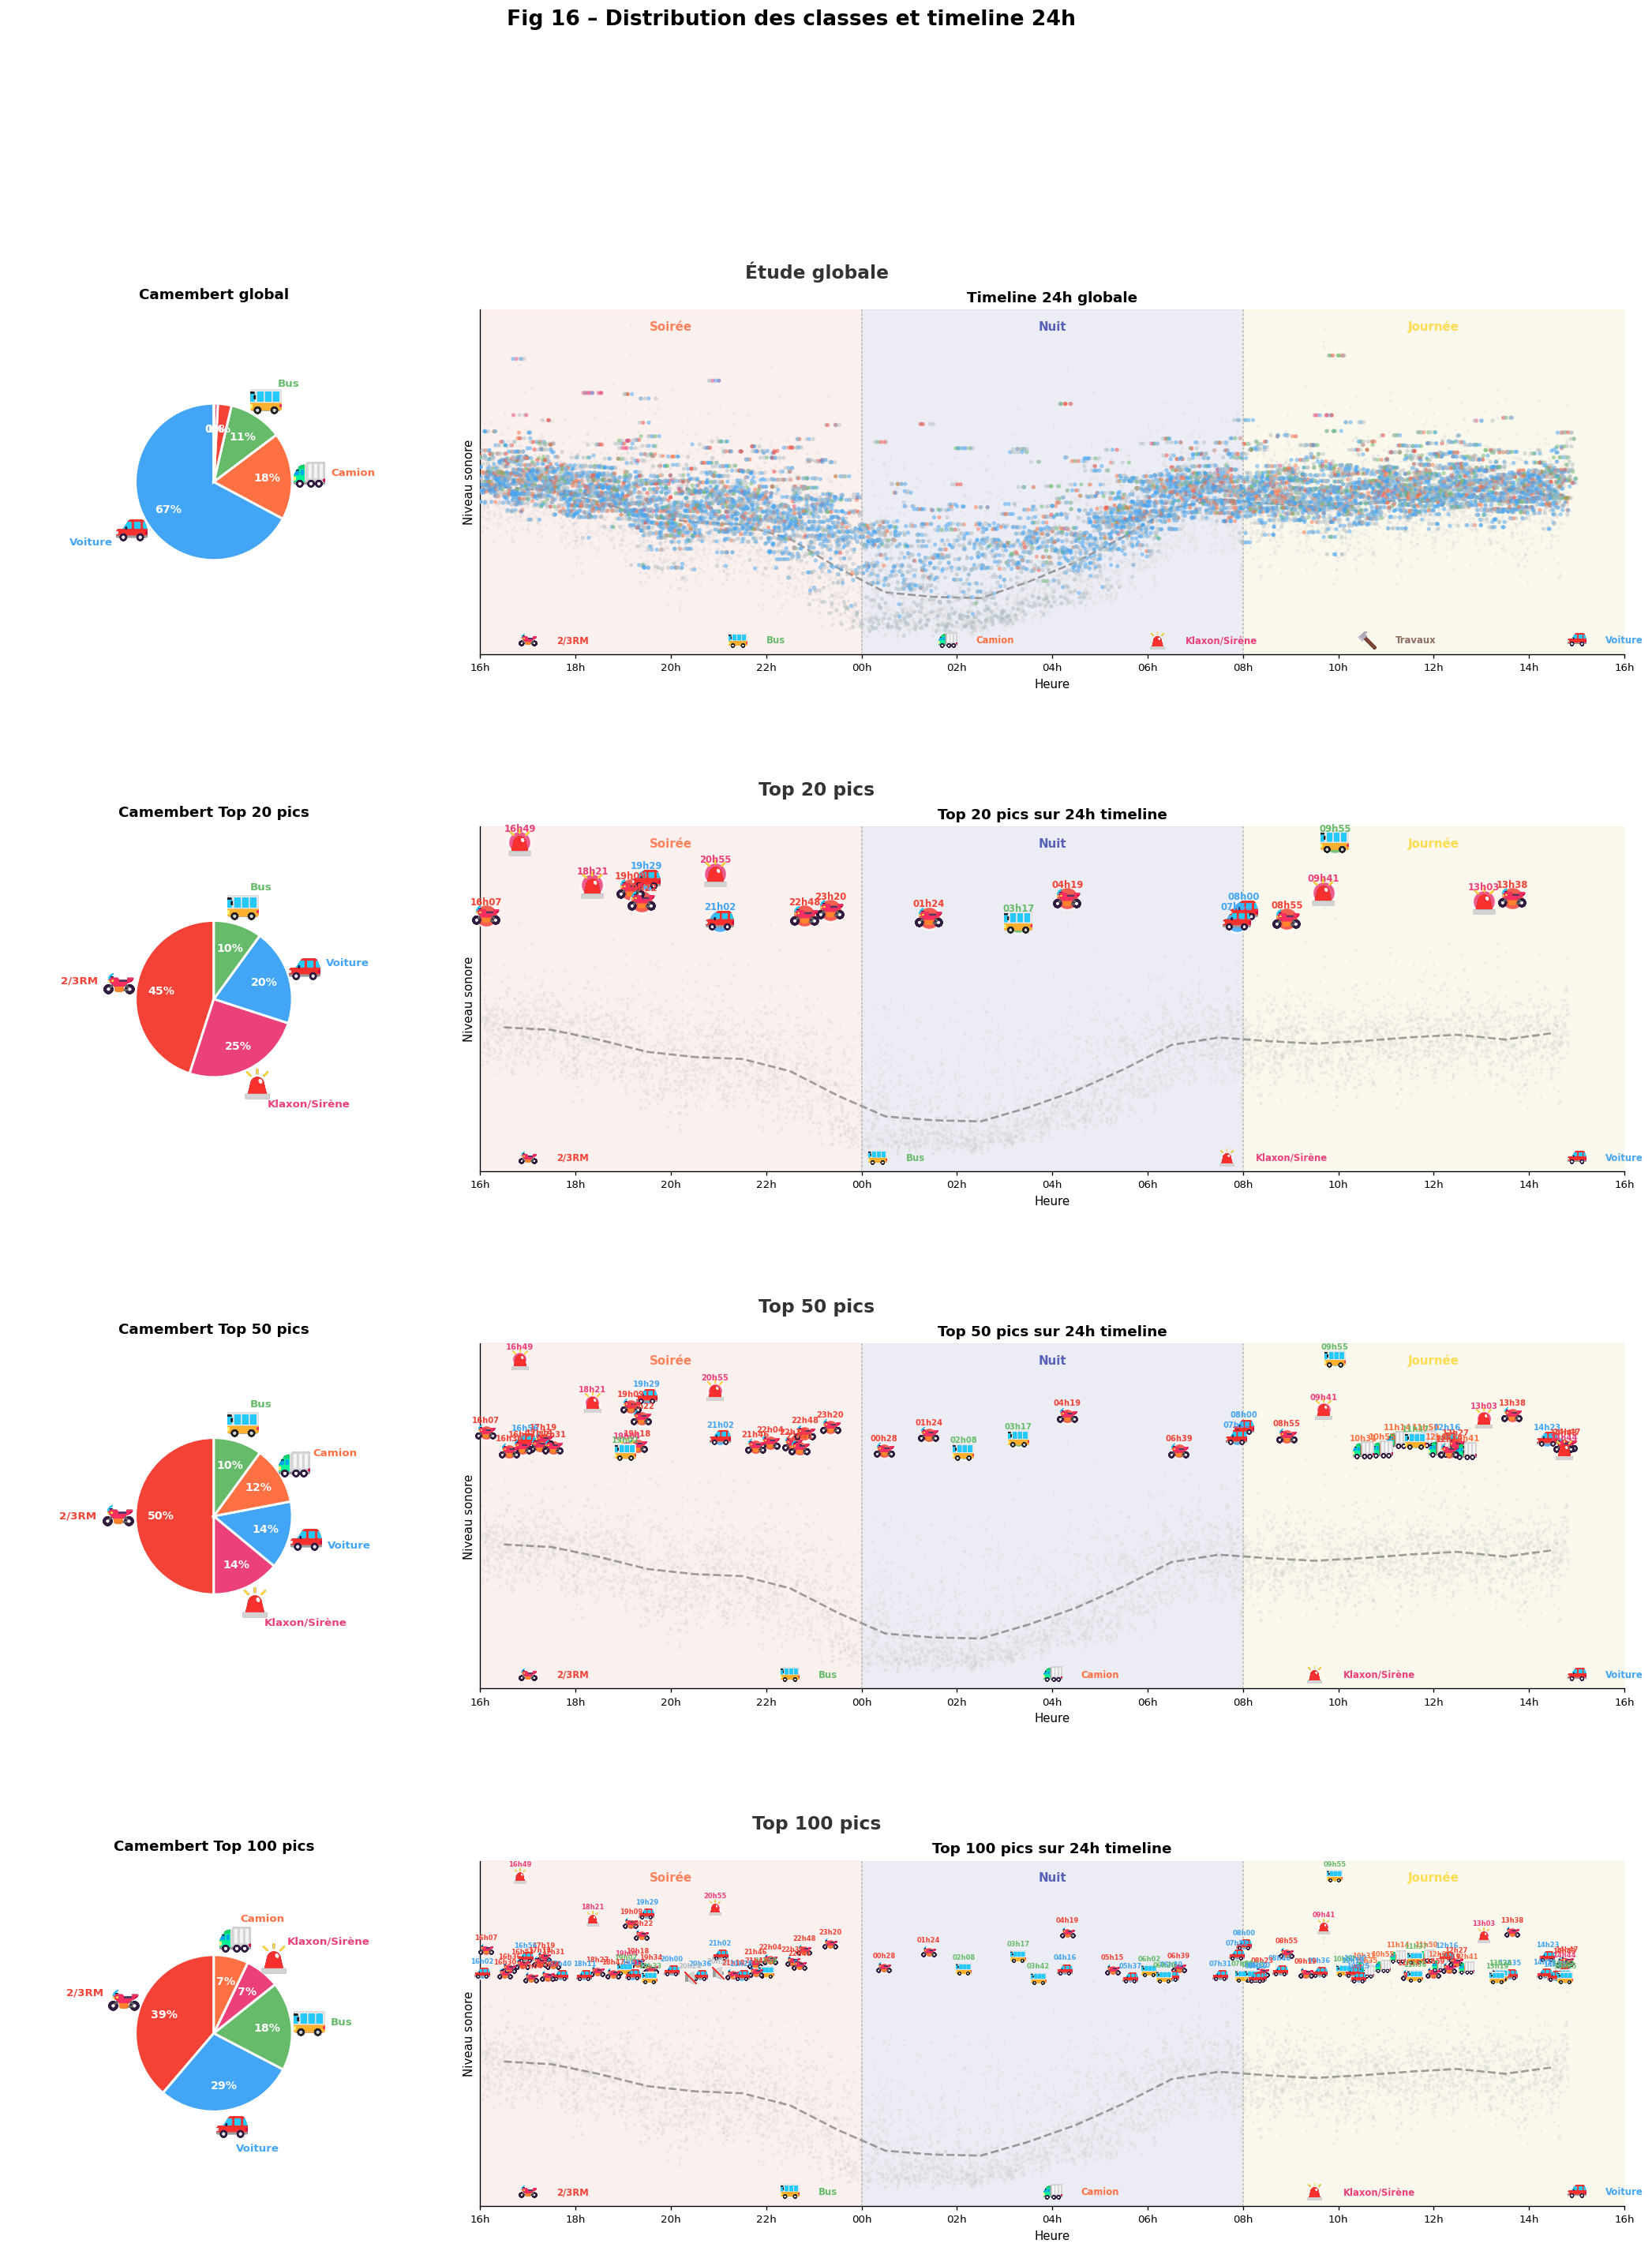

fig16_class_timeline.png sauvegardé.


In [8]:
# ── Légende horizontale en bas ────────────────────────────────────────────────
def _draw_bottom_legend(ax, classes):
    """Affiche une ligne de légende emoji+nom en bas du graphe."""
    legend_classes = sorted([c for c in classes if c not in ('Fond sonore', 'Tram')])
    if not legend_classes:
        return
    n = len(legend_classes)
    x_positions = np.linspace(17, 39, n)
    ylo, yhi = ax.get_ylim()
    y_leg = ylo + (yhi - ylo) * 0.04
    for cls, xpos in zip(legend_classes, x_positions):
        place_emoji(ax, to_emoji(cls), xpos, y_leg, zoom=0.13, zorder=11)
        ax.text(xpos + 0.6, y_leg, cls, va='center', fontsize=7,
                color=CLASS_COLORS.get(cls, '#333'), fontweight='bold', zorder=11)

# ── Données partagées ─────────────────────────────────────────────────────────
_hourly_mean = (
    df_peaks
    .assign(hour_bin=df_peaks['abs_hour'].apply(lambda h: int(h)))
    .groupby('hour_bin')['db_peak'].mean()
    .reindex(range(16, 40))
)
_sample_bg  = df_peaks.sample(min(6000, len(df_peaks)), random_state=42)
_all_counts = (df_events['class_norm']
               .value_counts()
               .drop(['BG', 'Tram', 'Fond sonore'], errors='ignore'))
db_map = df_files.set_index('filename')['db_rms'].to_dict()

ROWS = [
    ('all',  None,       'Étude globale',   'Camembert global',         'Timeline 24h globale'),
    ('topn', peaks_20,   'Top 20 pics',     'Camembert Top 20 pics',    'Top 20 pics sur 24h timeline'),
    ('topn', peaks_50,   'Top 50 pics',     'Camembert Top 50 pics',    'Top 50 pics sur 24h timeline'),
    ('topn', peaks_100,  'Top 100 pics',    'Camembert Top 100 pics',   'Top 100 pics sur 24h timeline'),
]

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Fig 16 – Distribution des classes et timeline 24h',
    fontsize=16, fontweight='bold', y=1.002)

gs = gridspec.GridSpec(4, 2, figure=fig,
                       width_ratios=[1, 2.8],
                       hspace=0.50, wspace=0.08)

for row_idx, (kind, df_n, row_title, pie_title, tl_title) in enumerate(ROWS):

    # ── Camembert (gauche) ────────────────────────────────────────────────────
    ax_pie = fig.add_subplot(gs[row_idx, 0])
    if kind == 'all':
        counts = _all_counts
    else:
        counts = (df_n['class_at_peak']
                  .value_counts()
                  .drop(['BG', 'Tram', 'Fond sonore'], errors='ignore'))
        if counts.empty:
            counts = df_n['class_at_peak'].value_counts()
    # Grand titre de ligne
    ax_row_title = fig.add_subplot(gs[row_idx, :])
    ax_row_title.set_axis_off()
    ax_row_title.text(0.5, 1.08, row_title, ha='center', va='bottom',
                      fontsize=14, fontweight='bold', transform=ax_row_title.transAxes,
                      color='#333')
    draw_pie_with_labels(ax_pie, counts, pie_title)

    # ── Timeline 24h (droite) ─────────────────────────────────────────────────
    ax_tl = fig.add_subplot(gs[row_idx, 1])
    ax_tl.set_facecolor('#fafafa')
    add_period_shading(ax_tl)

    # Nuage de fond
    ax_tl.scatter(
        _sample_bg['abs_hour'] + _sample_bg['t_peak'] / 3600,
        _sample_bg['db_peak'],
        c='#d4d4d4', s=2, alpha=0.20, zorder=1)

    # Moyenne horaire
    ax_tl.plot(_hourly_mean.index + 0.5, _hourly_mean.values,
               color='#555', linewidth=1.6, linestyle='--',
               alpha=0.55, zorder=2)

    if kind == 'all':
        # Nuage coloré par classe
        ev_plot = df_events[~df_events['class_norm'].isin(['BG', 'Tram'])].copy()
        ev_plot['db_file'] = ev_plot['filename'].map(db_map)
        ev_plot = ev_plot.dropna(subset=['db_file'])
        rng    = np.random.default_rng(0)
        jitter = rng.uniform(-0.20, 0.20, size=len(ev_plot))
        c_ev   = [CLASS_COLORS.get(c, '#999') for c in ev_plot['class_norm']]
        ax_tl.scatter(ev_plot['abs_hour'].values + jitter,
                      ev_plot['db_file'].values,
                      c=c_ev, s=5, alpha=0.38, zorder=3)

        # Légende en bas (commune à tous les graphiques)
        _draw_bottom_legend(ax_tl, ev_plot['class_norm'].unique())

    else:
        # Marqueurs top-N avec emoji centré
        n_pts = len(df_n)
        if   n_pts <= 20: msize, e_zoom = 300, 0.20
        elif n_pts <= 50: msize, e_zoom = 130, 0.15
        else:             msize, e_zoom =  60, 0.11

        for _, peak_row in df_n.iterrows():
            x     = peak_row['abs_hour'] + peak_row['t_peak'] / 3600
            y     = peak_row['db_peak']
            cls   = normalize_class(peak_row['class_at_peak'])
            color = CLASS_COLORS.get(cls, '#999')
            ax_tl.scatter(x, y, s=msize, color=color, zorder=6,
                          alpha=0.85, edgecolors='white', linewidths=1.4)
            place_emoji(ax_tl, to_emoji(cls), x, y,
                        zoom=e_zoom, zorder=7)
            # Afficher l'heure pour top-20, top-50, top-100
            real_h = int(x) % 24
            real_m = int((x % 1) * 60)
            time_label = f'{real_h:02d}h{real_m:02d}'
            fs = 7 if n_pts <= 20 else (6 if n_pts <= 50 else 5)
            ax_tl.text(x, y + (ax_tl.get_ylim()[1] - ax_tl.get_ylim()[0]) * 0.025,
                       time_label, ha='center', va='bottom', fontsize=fs,
                       color=color, fontweight='bold', zorder=8)
        # Légende en bas
        _draw_bottom_legend(ax_tl, df_n['class_at_peak'].apply(normalize_class).unique())

    # Étiquettes de période (sans emojis)
    ylo, yhi = ax_tl.get_ylim()
    for pname, ps, pe in period_ranges:
        mid_x = (ps + pe) / 2
        ax_tl.text(mid_x, yhi - (yhi - ylo) * 0.06,
                   pname, ha='center', fontsize=9,
                   color=PERIOD_COLORS[pname],
                   fontweight='bold', alpha=0.85, zorder=10)

    ax_tl.set_xlim(16, 40)
    ax_tl.set_title(tl_title, fontsize=11, fontweight='bold')
    # Axes x et y avec titres et horaires
    xtick_positions = list(range(16, 41, 2))
    xtick_labels = [f'{h % 24:02d}h' for h in xtick_positions]
    ax_tl.set_xticks(xtick_positions)
    ax_tl.set_xticklabels(xtick_labels, fontsize=8)
    ax_tl.set_xlabel('Heure', fontsize=9)
    ax_tl.set_ylabel('Niveau sonore', fontsize=9)
    ax_tl.set_yticks([])
    ax_tl.tick_params(axis='both', which='both', length=3)
    for spine in ['top', 'right']:
        ax_tl.spines[spine].set_visible(False)
    ax_tl.spines['bottom'].set_visible(True)
    ax_tl.spines['left'].set_visible(True)

plt.savefig('fig16_class_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig16_class_timeline.png sauvegardé.')